In [1]:
# Importing libraries

import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from pathlib import Path
import os

In [2]:
# Loading the model
model = YOLO('yolov8n.pt')

In [ ]:
# Custom training the model on dataset

# results = model.train(data=r'C:/Users/salma/OneDrive/Desktop/food_detection/data.yaml', epochs=50, batch=16, imgsz=640, device=0)

Ultralytics 8.3.213  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/salma/OneDrive/Desktop/food_detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [3]:
# Loading the custom trained model
detector = YOLO('C:/Users/salma/OneDrive/Desktop/food_detection/runs/detect/train8/weights/best.pt')


In [4]:
#list of food classes
classes = list(detector.names.values())
print("Detected classes:", classes)

Detected classes: ['Appam', 'Beetroot poriyal', 'Boiled Egg', 'Carrot poriyal', 'Chicken 65', 'Chicken briyani', 'Dosa', 'Idly', 'Kaara chutney', 'Kali', 'Koozh', 'Lemon Rice', 'Mushroom briyani', 'Mutton Briyani', 'Nandu masala', 'Nei satham', 'Paal kolukattai', 'Paneer briyani', 'Panner masala', 'Parupu vada', 'Pidi kolukattai', 'Poorna kolukattai', 'Prawn thokku', 'Puthina Chutney', 'Sambar', 'Sambar satham', 'Satham', 'Thengai chutney', 'Uzhuntha vadai', 'Veg briyani', 'Ven Pongal']


In [5]:
img_path = r'C:\Users\salma\OneDrive\Desktop\food_detection\data\train\images\1_png.rf.3efb4e4a90aafa527e247163a36aefc4.jpg'

results = detector(img_path, conf=0.25)  

boxes = results[0].boxes
detections = []

if boxes is None or len(boxes) == 0:
    print("No detections found!")
else:
    for box in boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        confidence = float(box.conf[0].cpu().numpy())
        class_id = int(box.cls[0].cpu().numpy())
        class_name = detector.names[class_id]
        detections.append({
            'bbox': (x1, y1, x2, y2),
            'confidence': confidence,
            'class': class_name
        })

    for i, det in enumerate(detections, 1):
        print(f"{i}. {det['class']} (confidence: {det['confidence']:.2%})")



image 1/1 C:\Users\salma\OneDrive\Desktop\food_detection\data\train\images\1_png.rf.3efb4e4a90aafa527e247163a36aefc4.jpg: 640x640 1 Dosa, 5.7ms
Speed: 4.8ms preprocess, 5.7ms inference, 15.9ms postprocess per image at shape (1, 3, 640, 640)
1. Dosa (confidence: 93.58%)


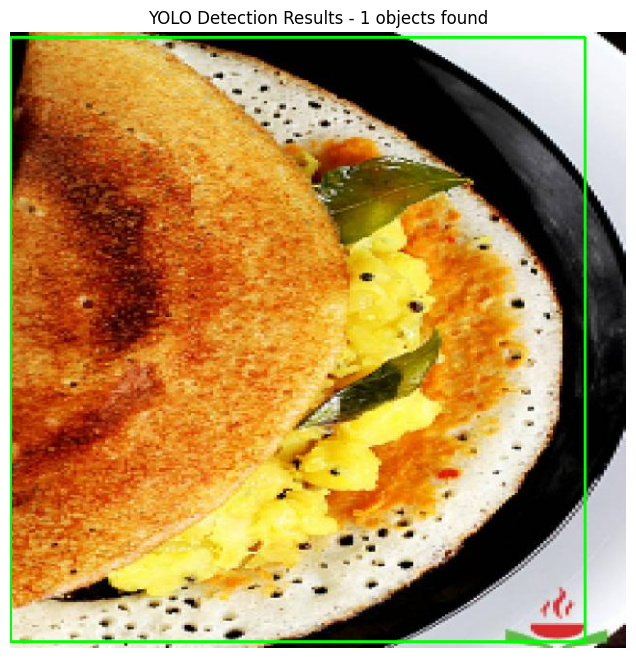

In [ ]:
# Load image 
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = image.shape[:2]

# Draw bounding boxes
annotated_img = image.copy()
for detection in detections:
    x1, y1, x2, y2 = detection['bbox']
    conf = detection['confidence']
    class_name = detector.names[class_id]


    #class_name = detection['class']
    cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = f"{class_name}: {conf:.2f}"
    cv2.putText(annotated_img, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    


plt.figure(figsize=(10,8))
plt.imshow(annotated_img)
plt.title(f"YOLO Detection Results - {len(detections)} objects found")
plt.axis('off')
plt.show()


In [7]:
for box in boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
    confidence = float(box.conf[0].cpu().numpy())
    class_id = int(box.cls[0].cpu().numpy())
    class_name = detector.names[class_id]  
    detections.append({
        'bbox': (x1, y1, x2, y2),
        'confidence': confidence,
        'class': class_name
    })

for i, det in enumerate(detections, 1):
    print(f"{i}. {det['class']} (confidence: {det['confidence']:.2%})")


1. Dosa (confidence: 93.58%)
2. Dosa (confidence: 93.58%)


In [9]:
metrics = model.val(data="data.yaml", imgsz=640, batch=16, conf=0.25, iou=0.6)

Ultralytics 8.3.213  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 20.825.7 MB/s, size: 55.9 KB)
val: Scanning C:\Users\salma\OneDrive\Desktop\food_detection\data\valid\labels.cache... 970 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 970/970  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 61/61 8.5it/s 7.2s0.1ss
                   all        970        981    0.00538    0.00416    0.00304    0.00265
                person         30         31      0.167      0.129     0.0941     0.0821
               bicycle         30         30          0          0          0          0
                   car         30         30          0          0          0          0
            motorcycle         29         32          0          0          0          0
              airplane         30         30          0          0          0   